<a href="https://colab.research.google.com/github/shlok-dhital/6CS012-AI-and-Machine-Learning/blob/main/ShlokDhital_2407091_Worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

# Preprocess data

Training set: (17024, 28, 28, 1), Labels: (17024, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


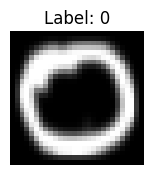

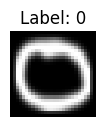

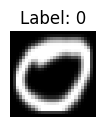

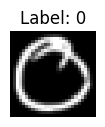

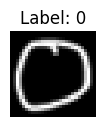

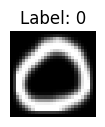

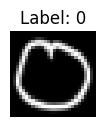

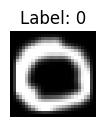

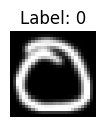

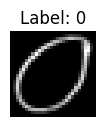

In [2]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/AI - ShlokDhital/DevanagariHandwrittenDigitDatasetExtracted/Train"
test_dir = "/content/drive/MyDrive/AI - ShlokDhital/DevanagariHandwrittenDigitDatasetExtracted/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []

  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels

  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    label = class_map[class_name]

    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)

      # Load image using PIL
      img = Image.open(img_path).convert("L") # Convert to grayscale
      img = img.resize((img_width, img_height)) # Resize to (28,28)
      img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
      images.append(img)
      labels.append(label)

  return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
  plt.show()

# Build FCN

In [3]:
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
  [
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
  ]
)

# Compile the model

In [8]:
model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics= ['accuracy']
)

# Fit the model

In [9]:
batch_size = 128
epochs = 100

print(x_train.shape)
print(y_train.shape)

history = model.fit(
  x_train,
  y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_split=0.2
)

(17024, 28, 28, 1)
(17024, 10)
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4427 - loss: 1.6877 - val_accuracy: 2.9369e-04 - val_loss: 6.9070
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8412 - loss: 0.5480 - val_accuracy: 8.8106e-04 - val_loss: 8.0028
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9307 - loss: 0.2596 - val_accuracy: 0.0012 - val_loss: 8.7240
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9485 - loss: 0.1811 - val_accuracy: 0.0012 - val_loss: 9.1535
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9596 - loss: 0.1403 - val_accuracy: 0.0012 - val_loss: 9.3201
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9686 - loss: 0.1123 - val_accuracy: 0.0012 - val_loss: 9.5096
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9739 - loss: 0.0928 - val_accuracy: 0.0012 - val_loss: 9.8707
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc

In [14]:
test_loss, test_acc= model.evaluate(x_test,y_test)
print(f"Test accuracy: {test_acc:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7867 - loss: 3.3506
Test accuracy: 0.7867


In [15]:
model.save('devnagiri.h5')

In [39]:
from keras.models import load_model

loaded_model = load_model("devnagiri.h5")
test_loss, test_acc= loaded_model.evaluate(x_test,y_test)
print(f"Test accuracy: {test_acc:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7867 - loss: 3.3506
Test accuracy: 0.7867


In [25]:
y_pred = loaded_model.predict(x_test)

y_pred_labels = np.argmax(y_pred, axis=1)

print(y_pred_labels)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[0 0 0 ... 1 0 1]


[[300   0   0   0   0   0   0   0   0   0]
 [  0 297   0   0   0   0   2   1   0   0]
 [  0   1 291   5   1   0   1   1   0   0]
 [  0   0   5 291   0   3   1   0   0   0]
 [  0   0   0   0 299   1   0   0   0   0]
 [  0   0   4   1   1 292   2   0   0   0]
 [  2   1   0   1   1   0 295   0   0   0]
 [  1   0   0   1   1   2   0 295   0   0]
 [128  13  56   1  50  10  31  11   0   0]
 [ 34  94   6   7  98   0  55   6   0   0]]


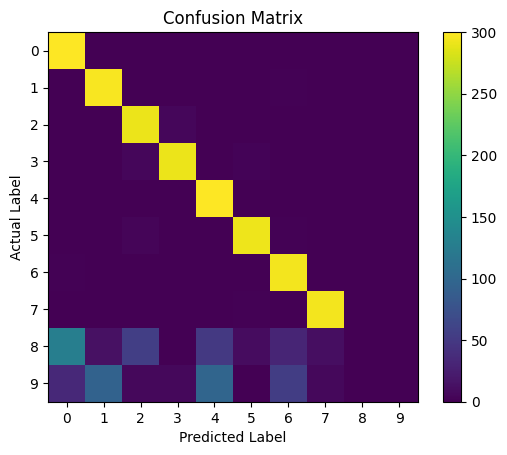

In [34]:
from sklearn.metrics import confusion_matrix

y_test_labels = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_test_labels, y_pred_labels)

print(cm)

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(np.arange(10))
plt.yticks(np.arange(10))

plt.colorbar()

plt.show()

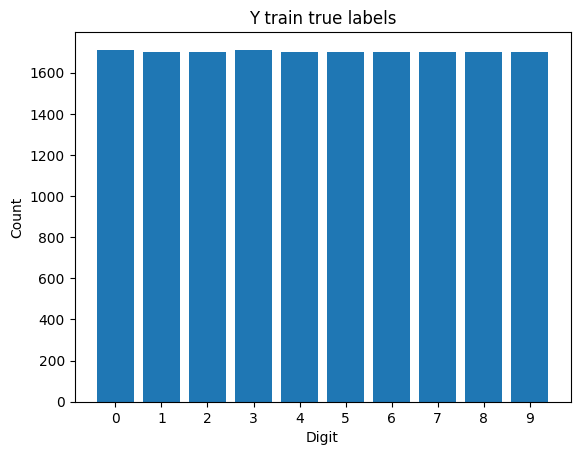

In [37]:
y_train_labels = np.argmax(y_train, axis=1)

counts = np.bincount(y_train_labels, minlength=10)

digits = np.arange(10)

plt.figure()
plt.bar(digits, counts)

plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("Y train true labels")

plt.xticks(digits)

plt.show()